## TÓPICOS ESPECIAIS EM SISTEMAS COMPUTACIONAIS II

#### Alunos:
João Felype Feitosa Rêgo 20250202545  
Andrey de Oliveira Sabino 2025022571

In [0]:
import pandas as pd

#Leitura dos dados.
path = "/Volumes/workspace/topicos_ll/dados_atividade_3/winequality-red.csv"

df = pd.read_csv(path, sep=";")
display(df)

fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.2,0.68,9.8,5
7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5
11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6
7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
7.4,0.66,0.0,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
7.9,0.6,0.06,1.6,0.069,15.0,59.0,0.9964,3.3,0.46,9.4,5
7.3,0.65,0.0,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
7.5,0.5,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.8,10.5,5


In [0]:
# Recodificando a coluna quality em ruim, medio e bom.
def classificar(q):
    if q <= 5:
        return "ruim"
    elif 6 <= q <= 7:
        return "medio"
    else:
        return "bom"

df["quality"] = df["quality"].apply(classificar)

# Removendo 'quality' da normalização por não ser uma variável numérica.
features = df.columns[df.columns != "quality"]

df_norm = df.copy()

# Normalizando os dados.
for c in features:
    mean = df[c].mean()
    std = df[c].std()
    
    df_norm[c] = (df[c] - mean) / std

display(df_norm)


fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
-0.5281943702487119,0.9615758497615481,-1.3910371025826427,-0.4530766652469418,-0.2436304687056834,-0.46604671805704423,-0.37901411729367046,0.5580998653531202,1.2882399009324956,-0.579025378566879,-0.9599457953606226,ruim
-0.29845406476685127,1.9668271476507617,-1.3910371025826427,0.04340256663998549,0.22380518049685513,0.8723653192008122,0.6241679617209318,0.028251929345806354,-0.7197081416221462,0.12891007217488806,-0.584594225308564,ruim
-0.29845406476685127,1.2966596157246195,-1.1856994924804343,-0.1693742470258406,0.09632273071434454,-0.08364327884051381,0.22897502150305818,0.13422151654725736,-0.3310730366115724,-0.04807379051055384,-0.584594225308564,ruim
1.654338531828966,-1.3840105119799495,1.4836894388482733,-0.4530766652469418,-0.26487754366943517,0.10755844076775137,0.4113717631420768,0.6640694525545712,-0.9787982116291973,-0.46103613677658495,-0.584594225308564,medio
-0.5281943702487119,0.9615758497615481,-1.3910371025826427,-0.4530766652469418,-0.2436304687056834,-0.46604671805704423,-0.37901411729367046,0.5580998653531202,1.2882399009324956,-0.579025378566879,-0.9599457953606226,ruim
-0.5281943702487119,0.7381866724528344,-1.3910371025826427,-0.524002269802217,-0.26487754366943517,-0.274844998448779,-0.19661737565465184,0.5580998653531202,1.2882399009324956,-0.579025378566879,-0.9599457953606226,ruim
-0.24101898839638572,0.403102906489763,-1.0830306874293303,-0.6658534789127676,-0.39235999345194544,-0.08364327884051381,0.3809723062022403,-0.18368724505715447,-0.0719829666045213,-1.1689715875183517,-0.9599457953606226,ruim
-0.5856294466191774,0.6823393781256558,-1.3910371025826427,-0.9495558971338689,-0.4773482933069525,-0.08364327884051381,-0.7742070575115441,-1.1374135298702723,0.5109696909113451,-1.1099769666232047,-0.3969184402825354,medio
-0.29845406476685127,0.29140831783540583,-1.2883682975315383,-0.38215106069166643,-0.30737169359693867,-0.6572484376653094,-0.8654054283310534,0.028251929345806354,0.3166521384060554,-0.5200307576717322,-0.8661079028476084,medio
-0.47075929387824683,-0.15537003678202213,0.45700138833723164,2.525798726074621,-0.3498658435244422,0.10755844076775137,1.6881489546152069,0.5580998653531202,0.251879620904294,0.836845522916655,0.07227102228253755,ruim


Resposta:
1. A normalização é essencial, pois o algoritmo se baseia na distância entre as amostras. Valores que estão em escalas diferentes podem exercer maior influência no cálculo, causando dominância na medida de distância e contribuindo de forma desigual entre as variáveis, reduzindo o impacto das demais.

In [0]:
from sklearn.model_selection import train_test_split

# Separando X e Y.
X = df_norm.drop("quality", axis=1)
y = df_norm["quality"]

# Dividindo treino e teste (80/20).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Verificação da proporção das classes.
print("Distribuição no conjunto original:")
print(y.value_counts(normalize=True))

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True))

Distribuição no conjunto original:
quality
medio    0.523452
ruim     0.465291
bom      0.011257
Name: proportion, dtype: float64

Distribuição no treino:
quality
medio    0.523847
ruim     0.465207
bom      0.010946
Name: proportion, dtype: float64

Distribuição no teste:
quality
medio    0.521875
ruim     0.465625
bom      0.012500
Name: proportion, dtype: float64


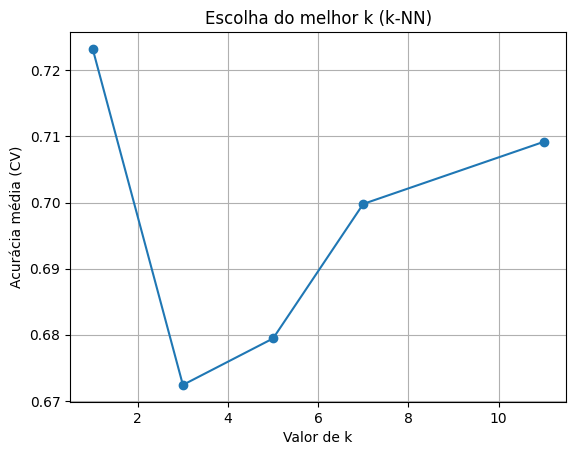

In [0]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Valores de K para serem testados.
k_values = [1, 3, 5, 7, 11]

acc_means = []

# Validação cruzada (5 folds).
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    acc_means.append(scores.mean())

# Plotagem do gráfico.
plt.figure()

plt.plot(k_values, acc_means, marker='o')

plt.xlabel("Valor de k")
plt.ylabel("Acurácia média (CV)")
plt.title("Escolha do melhor k (k-NN)")
plt.grid()

plt.show()

Resposta:
3. O valor de K=1, apesar de ter sido o que apresentou o maior valor de acurácia, tende a causar overfitting, pois o modelo se torna muito sensivel aos dados. Valores intermediarios como K=7 ou K=11 apresentam maior desepenho para um melhor resultado, além de maior capacidade de generalização e escalabilidade, sendo os valores mais adequados para o modelo. 

In [0]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Treinando o modelo com k=7.
k = 7

modelo = KNeighborsClassifier(n_neighbors=k)
modelo.fit(X_train, y_train)

# Previsões do modelo.
y_pred = modelo.predict(X_test)

# Montando a matriz de confusão.
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de confusão com K=7:")
print(matriz)

# Métricas de avaliação do modelo.
print("\nRelatório de classificação com k=7:")
print(classification_report(y_test, y_pred))

print("Acurácia:", accuracy_score(y_test, y_pred))

Matriz de confusão com K=7:
[[  0   4   0]
 [  0 144  23]
 [  0  44 105]]

Relatório de classificação com k=7:
              precision    recall  f1-score   support

         bom       0.00      0.00      0.00         4
       medio       0.75      0.86      0.80       167
        ruim       0.82      0.70      0.76       149

    accuracy                           0.78       320
   macro avg       0.52      0.52      0.52       320
weighted avg       0.77      0.78      0.77       320

Acurácia: 0.778125


/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Resposta:
4. O modelo apresenta mais erros entre as classes 'medio' e 'ruim', sendo a maior fonte de confusão.